# NumPy Advanced Exercises XP - Week 5 Day 2

Advanced NumPy operations including matrix algebra, statistical analysis, data manipulation, and visualization integration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Libraries imported successfully!
NumPy version: 2.3.3
Pandas version: 2.3.3
Matplotlib version: 3.10.7


## Exercise 1: Matrix Operations

In [2]:
# Creating a 3x3 matrix and performing matrix operations
matrix_3x3 = np.array([[2, 1, 3],
                       [1, 4, 2],
                       [3, 2, 1]])

print("Exercise 1 - Matrix Operations:")
print("3x3 Matrix:")
print(matrix_3x3)

# Calculating the determinant
determinant = np.linalg.det(matrix_3x3)
print(f"\nDeterminant: {determinant:.6f}")

# Finding the inverse of the matrix
try:
    matrix_inverse = np.linalg.inv(matrix_3x3)
    print(f"\nInverse Matrix:")
    print(matrix_inverse)
    
    # Verifying the inverse by multiplying with original matrix
    identity_check = np.dot(matrix_3x3, matrix_inverse)
    print(f"\nVerification (Original × Inverse = Identity):")
    print(np.round(identity_check, 6))
    
    # Checking if it's close to identity matrix
    is_identity = np.allclose(identity_check, np.eye(3))
    print(f"Is result close to identity matrix? {is_identity}")
    
except np.linalg.LinAlgError:
    print("Matrix is singular and cannot be inverted!")

print(f"\nAdditional Matrix Properties:")
print(f"Matrix rank: {np.linalg.matrix_rank(matrix_3x3)}")
print(f"Matrix trace (sum of diagonal): {np.trace(matrix_3x3)}")
print(f"Matrix condition number: {np.linalg.cond(matrix_3x3):.6f}")

Exercise 1 - Matrix Operations:
3x3 Matrix:
[[2 1 3]
 [1 4 2]
 [3 2 1]]

Determinant: -25.000000

Inverse Matrix:
[[ 0.   -0.2   0.4 ]
 [-0.2   0.28  0.04]
 [ 0.4   0.04 -0.28]]

Verification (Original × Inverse = Identity):
[[ 1. -0.  0.]
 [ 0.  1.  0.]
 [ 0. -0.  1.]]
Is result close to identity matrix? True

Additional Matrix Properties:
Matrix rank: 3
Matrix trace (sum of diagonal): 7
Matrix condition number: 3.766951


## Exercise 2: Statistical Analysis

Exercise 2 - Statistical Analysis:
Dataset of 50 random numbers:
First 10 values: [54.96714153 48.61735699 56.47688538 65.23029856 47.65846625 47.65863043
 65.79212816 57.67434729 45.30525614 55.42560044]

Statistical Measures:
Mean: 47.7453
Median: 47.6585
Standard Deviation (population): 9.2428
Standard Deviation (sample): 9.3367

Additional Statistics:
Minimum value: 30.4033
Maximum value: 68.5228
Range: 38.1195
Variance: 85.4303
25th percentile: 41.3902
75th percentile: 53.3628


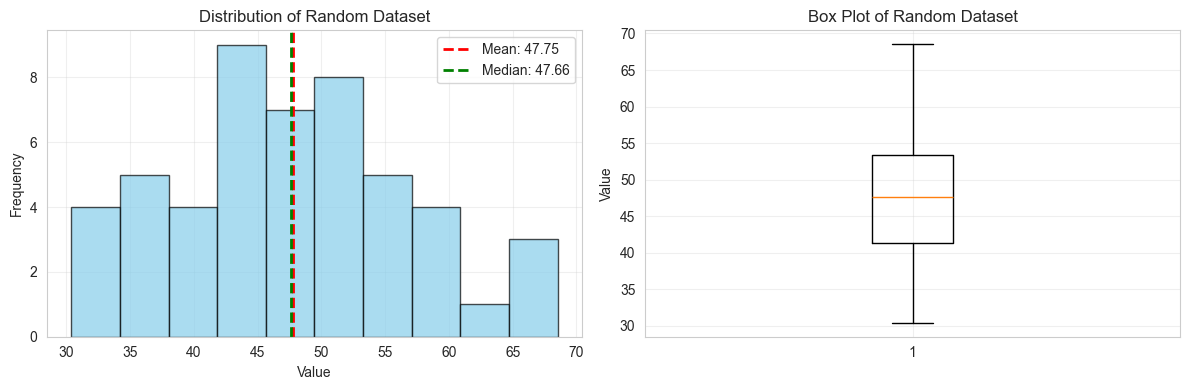

In [3]:
# Generating array of 50 random numbers for statistical analysis
np.random.seed(42)
random_dataset = np.random.randn(50) * 10 + 50  # Normal distribution with mean=50, std=10

print("Exercise 2 - Statistical Analysis:")
print(f"Dataset of 50 random numbers:")
print(f"First 10 values: {random_dataset[:10]}")

# Calculating mean and median
dataset_mean = np.mean(random_dataset)
dataset_median = np.median(random_dataset)

print(f"\nStatistical Measures:")
print(f"Mean: {dataset_mean:.4f}")
print(f"Median: {dataset_median:.4f}")

# Calculating standard deviation
dataset_std = np.std(random_dataset)
dataset_std_ddof = np.std(random_dataset, ddof=1)  

print(f"Standard Deviation (population): {dataset_std:.4f}")
print(f"Standard Deviation (sample): {dataset_std_ddof:.4f}")


print(f"\nAdditional Statistics:")
print(f"Minimum value: {np.min(random_dataset):.4f}")
print(f"Maximum value: {np.max(random_dataset):.4f}")
print(f"Range: {np.ptp(random_dataset):.4f}")
print(f"Variance: {np.var(random_dataset):.4f}")
print(f"25th percentile: {np.percentile(random_dataset, 25):.4f}")
print(f"75th percentile: {np.percentile(random_dataset, 75):.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(random_dataset, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(dataset_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {dataset_mean:.2f}')
plt.axvline(dataset_median, color='green', linestyle='--', linewidth=2, label=f'Median: {dataset_median:.2f}')
plt.title('Distribution of Random Dataset')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(random_dataset)
plt.title('Box Plot of Random Dataset')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exercise 3: Date Manipulation

In [4]:
# Creating NumPy array of dates for January 2023
print("Exercise 3 - Date Manipulation:")

# Creating dates for January 2023
january_2023_dates = np.arange('2023-01-01', '2023-02-01', dtype='datetime64[D]')

print("Original dates (YYYY-MM-DD format):")
print(january_2023_dates[:10])  # First 10 dates
print(f"Total dates in January 2023: {len(january_2023_dates)}")

# Converting to different formats
print(f"\nDate Format Conversions:")

# Converting to string format YYYY/MM/DD
dates_slash_format = np.datetime_as_string(january_2023_dates, unit='D')
dates_slash_format = np.char.replace(dates_slash_format, '-', '/')

print("YYYY/MM/DD format:")
print(dates_slash_format[:5])

# Converting to different string representations
print("\nAlternative date formats:")
for i, date in enumerate(january_2023_dates[:5]):
    date_obj = date.astype(datetime)
    print(f"Date {i+1}:")
    print(f"  Standard: {date}")
    print(f"  YYYY/MM/DD: {dates_slash_format[i]}")
    print(f"  DD-MM-YYYY: {date_obj.strftime('%d-%m-%Y')}")
    print(f"  Month DD, YYYY: {date_obj.strftime('%B %d, %Y')}")
    print(f"  Weekday: {date_obj.strftime('%A')}")

# Working with date arrays
print(f"\nDate Array Operations:")
print(f"First date: {january_2023_dates[0]}")
print(f"Last date: {january_2023_dates[-1]}")
print(f"Middle date: {january_2023_dates[len(january_2023_dates)//2]}")

# Finding specific dates
weekdays = np.array([pd.Timestamp(date).weekday() for date in january_2023_dates])
mondays = january_2023_dates[weekdays == 0]
fridays = january_2023_dates[weekdays == 4]

print(f"Mondays in January 2023: {len(mondays)}")
print(f"First Monday: {mondays[0]}")
print(f"Fridays in January 2023: {len(fridays)}")
print(f"Last Friday: {fridays[-1]}")

Exercise 3 - Date Manipulation:
Original dates (YYYY-MM-DD format):
['2023-01-01' '2023-01-02' '2023-01-03' '2023-01-04' '2023-01-05'
 '2023-01-06' '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10']
Total dates in January 2023: 31

Date Format Conversions:
YYYY/MM/DD format:
['2023/01/01' '2023/01/02' '2023/01/03' '2023/01/04' '2023/01/05']

Alternative date formats:
Date 1:
  Standard: 2023-01-01
  YYYY/MM/DD: 2023/01/01
  DD-MM-YYYY: 01-01-2023
  Month DD, YYYY: January 01, 2023
  Weekday: Sunday
Date 2:
  Standard: 2023-01-02
  YYYY/MM/DD: 2023/01/02
  DD-MM-YYYY: 02-01-2023
  Month DD, YYYY: January 02, 2023
  Weekday: Monday
Date 3:
  Standard: 2023-01-03
  YYYY/MM/DD: 2023/01/03
  DD-MM-YYYY: 03-01-2023
  Month DD, YYYY: January 03, 2023
  Weekday: Tuesday
Date 4:
  Standard: 2023-01-04
  YYYY/MM/DD: 2023/01/04
  DD-MM-YYYY: 04-01-2023
  Month DD, YYYY: January 04, 2023
  Weekday: Wednesday
Date 5:
  Standard: 2023-01-05
  YYYY/MM/DD: 2023/01/05
  DD-MM-YYYY: 05-01-2023
  Month

## Exercise 4: Data Manipulation with NumPy and Pandas

In [5]:
#  DataFrame with random numbers for data manipulation
print("Exercise 4 - Data Manipulation with NumPy and Pandas:")

#  random data
np.random.seed(123)
data = {
    'A': np.random.randn(100) * 10 + 50,
    'B': np.random.randn(100) * 5 + 25,
    'C': np.random.randint(1, 100, 100),
    'Category': np.random.choice(['X', 'Y', 'Z'], 100)
}

df = pd.DataFrame(data)
print("DataFrame created:")
print(df.head(10))
print(f"DataFrame shape: {df.shape}")

# Conditional selection of data
print(f"\nConditional Selection Examples:")

# Selecting rows where column A > 55
condition_a = df['A'] > 55
selected_a = df[condition_a]
print(f"Rows where A > 55: {len(selected_a)} rows")
print(selected_a[['A', 'B', 'C']].head())

# Multiple conditions
complex_condition = (df['A'] > 50) & (df['B'] < 30) & (df['Category'] == 'X')
selected_complex = df[complex_condition]
print(f"\nRows where A > 50 AND B < 30 AND Category = 'X': {len(selected_complex)} rows")

# Selecting data based on quantiles
q75_a = df['A'].quantile(0.75)
top_25_percent = df[df['A'] > q75_a]
print(f"\nTop 25% based on column A (A > {q75_a:.2f}): {len(top_25_percent)} rows")

# Aggregation functions
print(f"\nAggregation Functions:")
print(f"Sum of all numeric columns:")
print(df[['A', 'B', 'C']].sum())

print(f"\nAverage of all numeric columns:")
print(df[['A', 'B', 'C']].mean())

# Grouped aggregations
print(f"\nGrouped Aggregations by Category:")
grouped_stats = df.groupby('Category')[['A', 'B', 'C']].agg(['mean', 'sum', 'count'])
print(grouped_stats)

# Advanced aggregations
print(f"\nAdvanced Aggregations:")
print(f"Overall statistics:")
print(df.describe())

# Custom aggregation functions
custom_agg = df[['A', 'B', 'C']].agg({
    'A': ['min', 'max', 'std'],
    'B': ['median', 'var'],
    'C': ['sum', 'mean']
})
print(f"\nCustom aggregations:")
print(custom_agg)

Exercise 4 - Data Manipulation with NumPy and Pandas:
DataFrame created:
           A          B   C Category
0  39.143694  28.210273  38        Y
1  59.973454  15.110560  95        Y
2  52.829785  28.561323  20        Z
3  34.937053  37.991520  59        Z
4  44.213997  24.876870   7        Z
5  66.514365  25.170711  91        Y
6  25.733208  25.897747  72        Y
7  45.710874  15.690121  78        Y
8  62.659363  27.130733  79        X
9  41.332596  16.972951  71        X
DataFrame shape: (100, 4)

Conditional Selection Examples:
Rows where A > 55: 35 rows
            A          B   C
1   59.973454  15.110560  95
5   66.514365  25.170711  91
8   62.659363  27.130733  79
12  64.913896  21.323915  98
16  72.059301  18.145258  95

Rows where A > 50 AND B < 30 AND Category = 'X': 18 rows

Top 25% based on column A (A > 59.83): 25 rows

Aggregation Functions:
Sum of all numeric columns:
A    5027.109073
B    2490.232219
C    5459.000000
dtype: float64

Average of all numeric columns:
A  

## Exercise 5: Image Representation

Exercise 5 - Image Representation:
How images are represented in NumPy arrays:
---------------------------------------------
Images in NumPy are represented as multi-dimensional arrays:
• Grayscale images: 2D arrays (height × width)
• Color images: 3D arrays (height × width × channels)
• Pixel values typically range from 0-255 (uint8) or 0-1 (float)

Creating a 5x5 grayscale image:
Grayscale image array (0=black, 255=white):
[[  0  50 100 150 200]
 [ 50 100 150 200 255]
 [100 150 200 255 200]
 [150 200 255 200 150]
 [200 255 200 150 100]]
Image shape: (5, 5)
Data type: int64
Value range: 0 to 255

Different image patterns:
Checkerboard pattern (8x8):
[[  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]]

Horizontal gradient (5x5):
[[  0   0   0   0   0]
 [ 63  63

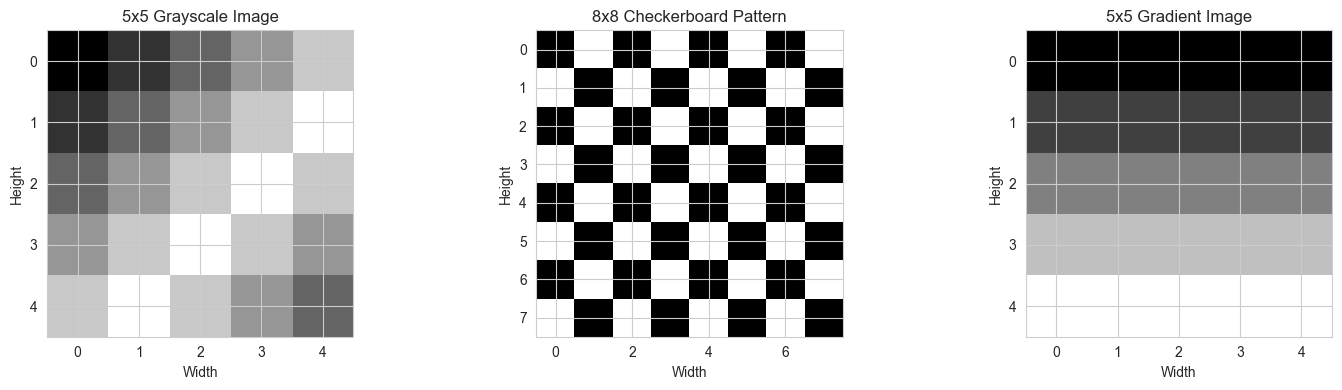


Creating a simple RGB color image (3x3x3):
RGB image array shape: (3, 3, 3)
Red channel:
[[255 255 255]
 [  0   0   0]
 [  0   0   0]]
Green channel:
[[  0   0   0]
 [255 255 255]
 [  0   0   0]]
Blue channel:
[[  0   0   0]
 [  0   0   0]
 [255 255 255]]


In [6]:
print("Exercise 5 - Image Representation:")
print("How images are represented in NumPy arrays:")
print("-" * 45)

print("Images in NumPy are represented as multi-dimensional arrays:")
print("• Grayscale images: 2D arrays (height × width)")
print("• Color images: 3D arrays (height × width × channels)")
print("• Pixel values typically range from 0-255 (uint8) or 0-1 (float)")

# Creating a simple 5x5 grayscale image
print(f"\nCreating a 5x5 grayscale image:")

# Method 1: Manual creation with specific pattern
grayscale_image = np.array([
    [0,   50,  100, 150, 200],
    [50,  100, 150, 200, 255],
    [100, 150, 200, 255, 200],
    [150, 200, 255, 200, 150],
    [200, 255, 200, 150, 100]
])

print("Grayscale image array (0=black, 255=white):")
print(grayscale_image)
print(f"Image shape: {grayscale_image.shape}")
print(f"Data type: {grayscale_image.dtype}")
print(f"Value range: {grayscale_image.min()} to {grayscale_image.max()}")

# Creating different pattern examples
print(f"\nDifferent image patterns:")

# Checkerboard pattern
checkerboard = np.zeros((8, 8))
checkerboard[1::2, ::2] = 255
checkerboard[::2, 1::2] = 255
print(f"Checkerboard pattern (8x8):")
print(checkerboard.astype(int))

# Gradient image
gradient = np.zeros((5, 5))
for i in range(5):
    gradient[i, :] = i * 63.75  # Creates horizontal gradient
print(f"\nHorizontal gradient (5x5):")
print(gradient.astype(int))

# Visualizing the images
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original grayscale image
axes[0].imshow(grayscale_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('5x5 Grayscale Image')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Height')

# Checkerboard
axes[1].imshow(checkerboard, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('8x8 Checkerboard Pattern')
axes[1].set_xlabel('Width')
axes[1].set_ylabel('Height')

# Gradient
axes[2].imshow(gradient, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('5x5 Gradient Image')
axes[2].set_xlabel('Width')
axes[2].set_ylabel('Height')

plt.tight_layout()
plt.show()

# Creating a simple RGB color image
print(f"\nCreating a simple RGB color image (3x3x3):")
rgb_image = np.zeros((3, 3, 3), dtype=np.uint8)
rgb_image[0, :, 0] = 255  # Red row
rgb_image[1, :, 1] = 255  # Green row  
rgb_image[2, :, 2] = 255  # Blue row

print("RGB image array shape:", rgb_image.shape)
print("Red channel:")
print(rgb_image[:, :, 0])
print("Green channel:")
print(rgb_image[:, :, 1])
print("Blue channel:")
print(rgb_image[:, :, 2])

## Exercise 6: Basic Hypothesis Testing

Exercise 6 - Basic Hypothesis Testing:
Testing the effectiveness of a new training program on employee productivity
----------------------------------------------------------------------
Sample Data:
Before training (first 10): [54.96714153 48.61735699 56.47688538 65.23029856 47.65846625 47.65863043
 65.79212816 57.67434729 45.30525614 55.42560044]
After training (first 10): [58.16202169 59.17419154 61.43639371 67.05716578 55.12610099 48.99609948
 71.41871894 56.79533692 46.32069799 61.01618414]

Hypothesis Formulation:
H0 (Null): The training program has no effect (mean difference = 0)
H1 (Alternative): The training program improves productivity (mean difference > 0)

Descriptive Statistics:
Before training - Mean: 48.12, Std: 8.85
After training - Mean: 52.76, Std: 9.52

Difference Analysis:
Mean difference: 4.64
Standard deviation of differences: 2.75
Number of employees: 30

Basic t-test calculation:
Standard error: 0.5014
t-statistic: 9.2469
Effect size (Cohen's d): 0.5045

Interp

C:\Users\PC\AppData\Local\Temp\ipykernel_15520\1974868464.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([productivity_before, productivity_after], labels=['Before', 'After'])


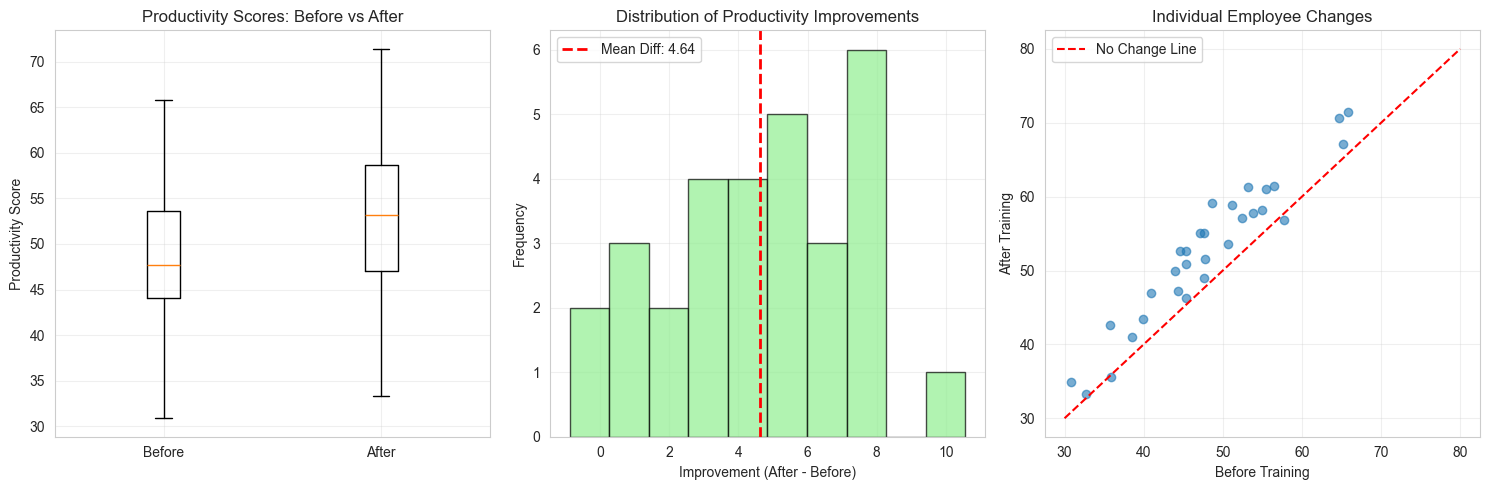


Conclusion:
The training program appears to be effective in improving productivity.


In [7]:
print("Exercise 6 - Basic Hypothesis Testing:")
print("Testing the effectiveness of a new training program on employee productivity")
print("-" * 70)

# Setting random seed for reproducible results
np.random.seed(42)

# Productivity scores of employees before the training program
productivity_before = np.random.normal(loc=50, scale=10, size=30)

# Productivity scores of the same employees after the training program
productivity_after = productivity_before + np.random.normal(loc=5, scale=3, size=30)

print("Sample Data:")
print(f"Before training (first 10): {productivity_before[:10]}")
print(f"After training (first 10): {productivity_after[:10]}")

# Formulating the hypothesis
print(f"\nHypothesis Formulation:")
print("H0 (Null): The training program has no effect (mean difference = 0)")
print("H1 (Alternative): The training program improves productivity (mean difference > 0)")

#  statistical analysis
print(f"\nDescriptive Statistics:")
print(f"Before training - Mean: {np.mean(productivity_before):.2f}, Std: {np.std(productivity_before):.2f}")
print(f"After training - Mean: {np.mean(productivity_after):.2f}, Std: {np.std(productivity_after):.2f}")

# Calculating the difference
productivity_difference = productivity_after - productivity_before
mean_difference = np.mean(productivity_difference)
std_difference = np.std(productivity_difference)

print(f"\nDifference Analysis:")
print(f"Mean difference: {mean_difference:.2f}")
print(f"Standard deviation of differences: {std_difference:.2f}")
print(f"Number of employees: {len(productivity_difference)}")

#  hypothesis test using t-statistic
n = len(productivity_difference)
standard_error = std_difference / np.sqrt(n)
t_statistic = mean_difference / standard_error

print(f"\nBasic t-test calculation:")
print(f"Standard error: {standard_error:.4f}")
print(f"t-statistic: {t_statistic:.4f}")

# Effect size (Cohen's d)
pooled_std = np.sqrt((np.std(productivity_before)**2 + np.std(productivity_after)**2) / 2)
cohens_d = mean_difference / pooled_std

print(f"Effect size (Cohen's d): {cohens_d:.4f}")

print(f"\nInterpretation:")
print(f"• The training program shows an average improvement of {mean_difference:.2f} points")
print(f"• {np.sum(productivity_difference > 0)} out of {n} employees showed improvement")
print(f"• Percentage of employees who improved: {(np.sum(productivity_difference > 0)/n)*100:.1f}%")

if cohens_d < 0.2:
    effect_size = "small"
elif cohens_d < 0.5:
    effect_size = "small to medium"
elif cohens_d < 0.8:
    effect_size = "medium to large"
else:
    effect_size = "large"

print(f"• Effect size is considered: {effect_size}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.boxplot([productivity_before, productivity_after], labels=['Before', 'After'])
plt.title('Productivity Scores: Before vs After')
plt.ylabel('Productivity Score')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(productivity_difference, bins=10, alpha=0.7, color='lightgreen', edgecolor='black')
plt.axvline(mean_difference, color='red', linestyle='--', linewidth=2, 
           label=f'Mean Diff: {mean_difference:.2f}')
plt.title('Distribution of Productivity Improvements')
plt.xlabel('Improvement (After - Before)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(productivity_before, productivity_after, alpha=0.6)
plt.plot([30, 80], [30, 80], 'r--', label='No Change Line')
plt.xlabel('Before Training')
plt.ylabel('After Training')
plt.title('Individual Employee Changes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConclusion:")
if t_statistic > 2: 
    print("The training program appears to be effective in improving productivity.")
else:
    print("The evidence for training program effectiveness is not strong.")

## Exercise 7: Complex Array Comparison

Exercise 7 - Complex Array Comparison:
Array comparison analysis:
Array 1: [ 9  4  8 16 17 11  3  3  3 15  3 18 17 16  5]
Array 2: [12 17 10  3 13  5  2 14  5  5  4  8 18 16  2]

Element-wise comparison (Array1 > Array2):
Boolean result: [False False False  True  True  True  True False False  True False  True
 False False  True]

Detailed Comparison Analysis:
Elements where Array1 > Array2: 7 out of 15
Percentage where Array1 is greater: 46.7%
Indices where Array1 > Array2: [ 3  4  5  6  9 11 14]
Values where Array1 > Array2:
  Index 3: 16 > 3
  Index 4: 17 > 13
  Index 5: 11 > 5
  Index 6: 3 > 2
  Index 9: 15 > 5
  Index 11: 18 > 8
  Index 14: 5 > 2

Additional Comparison Operations:
Equal elements: 1 (6.7%)
Array1 < Array2: 7 (46.7%)

Complex Comparison Conditions:
Array1 > Array2 + 5: 4 elements
Close values (diff ≤ 2): 6 elements

2D Array Comparison Example:
Matrix 1:
[[8 8 1 3]
 [4 3 6 9]
 [2 1 8 7]]
Matrix 2:
[[3 1 9 3]
 [6 2 9 2]
 [6 5 3 9]]
Comparison result (Matrix1 > Matrix2

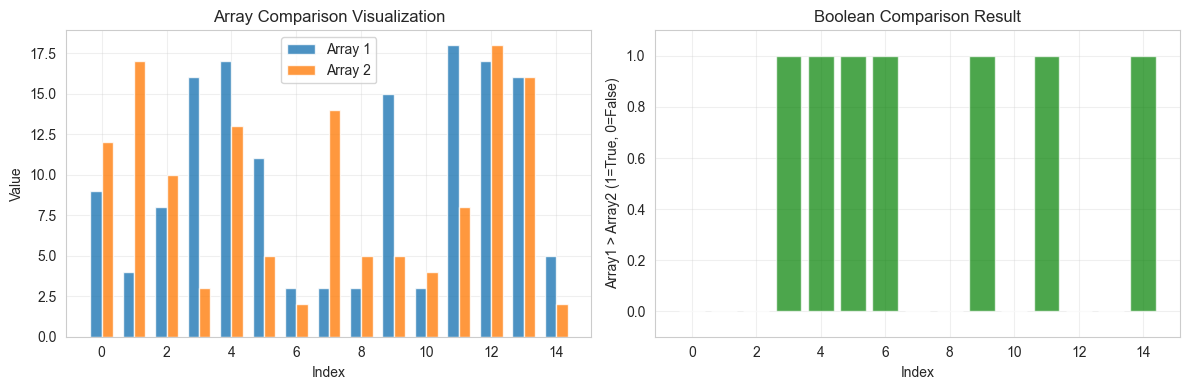

In [8]:
# Creating two arrays for element-wise comparison
print("Exercise 7 - Complex Array Comparison:")

# Creating two arrays with different patterns
np.random.seed(100)
array1 = np.random.randint(1, 20, size=15)
array2 = np.random.randint(1, 20, size=15)

print("Array comparison analysis:")
print(f"Array 1: {array1}")
print(f"Array 2: {array2}")

# Element-wise comparison to find which elements are greater in first array
comparison_result = array1 > array2

print(f"\nElement-wise comparison (Array1 > Array2):")
print(f"Boolean result: {comparison_result}")

# Additional comparison analyses
print(f"\nDetailed Comparison Analysis:")
print(f"Elements where Array1 > Array2: {np.sum(comparison_result)} out of {len(array1)}")
print(f"Percentage where Array1 is greater: {(np.sum(comparison_result)/len(array1))*100:.1f}%")

# Finding specific indices
greater_indices = np.where(comparison_result)[0]
print(f"Indices where Array1 > Array2: {greater_indices}")

# Showing the actual values at those indices
if len(greater_indices) > 0:
    print(f"Values where Array1 > Array2:")
    for idx in greater_indices:
        print(f"  Index {idx}: {array1[idx]} > {array2[idx]}")

print(f"\nAdditional Comparison Operations:")
equal_elements = array1 == array2
less_elements = array1 < array2

print(f"Equal elements: {np.sum(equal_elements)} ({(np.sum(equal_elements)/len(array1))*100:.1f}%)")
print(f"Array1 < Array2: {np.sum(less_elements)} ({(np.sum(less_elements)/len(array1))*100:.1f}%)")

# Multiple comparison conditions
print(f"\nComplex Comparison Conditions:")
much_greater = array1 > (array2 + 5)  # Array1 is at least 5 more than Array2
print(f"Array1 > Array2 + 5: {np.sum(much_greater)} elements")

close_values = np.abs(array1 - array2) <= 2  # Difference is 2 or less
print(f"Close values (diff ≤ 2): {np.sum(close_values)} elements")

#  2D arrays
print(f"\n2D Array Comparison Example:")
matrix1 = np.random.randint(1, 10, size=(3, 4))
matrix2 = np.random.randint(1, 10, size=(3, 4))

print("Matrix 1:")
print(matrix1)
print("Matrix 2:")
print(matrix2)

matrix_comparison = matrix1 > matrix2
print("Comparison result (Matrix1 > Matrix2):")
print(matrix_comparison)

# Using comparison for data filtering
filtered_array1 = array1[comparison_result]
filtered_array2 = array2[comparison_result]

print(f"\nFiltered data where Array1 > Array2:")
print(f"Array1 values: {filtered_array1}")
print(f"Array2 values: {filtered_array2}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
indices = np.arange(len(array1))
width = 0.35
plt.bar(indices - width/2, array1, width, label='Array 1', alpha=0.8)
plt.bar(indices + width/2, array2, width, label='Array 2', alpha=0.8)
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Array Comparison Visualization')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
comparison_int = comparison_result.astype(int)
plt.bar(indices, comparison_int, color='green', alpha=0.7)
plt.xlabel('Index')
plt.ylabel('Array1 > Array2 (1=True, 0=False)')
plt.title('Boolean Comparison Result')
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exercise 8: Time Series Data Manipulation

Exercise 8 - Time Series Data Manipulation:
Generated 365 dates for year 2023
Date range: 2023-01-01 to 2023-12-31
Sample temperature values: [12.45626309 20.36108289 17.66912338 13.7084287  28.34832217 19.16180997
 17.89954641 27.40911974 15.90159773 15.93026139]

Time Series Slicing Demonstrations:

1. January to March:
   Period: 2023-01-01 to 2023-03-31
   Number of days: 90
   Average temperature: 29.70°C

2. April to June:
   Period: 2023-04-01 to 2023-06-30
   Number of days: 91
   Average temperature: 28.63°C

3. July to September:
   Period: 2023-07-01 to 2023-09-30
   Number of days: 92
   Average temperature: 10.84°C

4. October to December:
   Period: 2023-10-01 to 2023-12-31
   Number of days: 92
   Average temperature: 10.08°C

Additional Time Series Slicing Examples:
Summer average temperature: 16.15°C
Winter average temperature: 23.34°C
July average temperature: 16.53°C


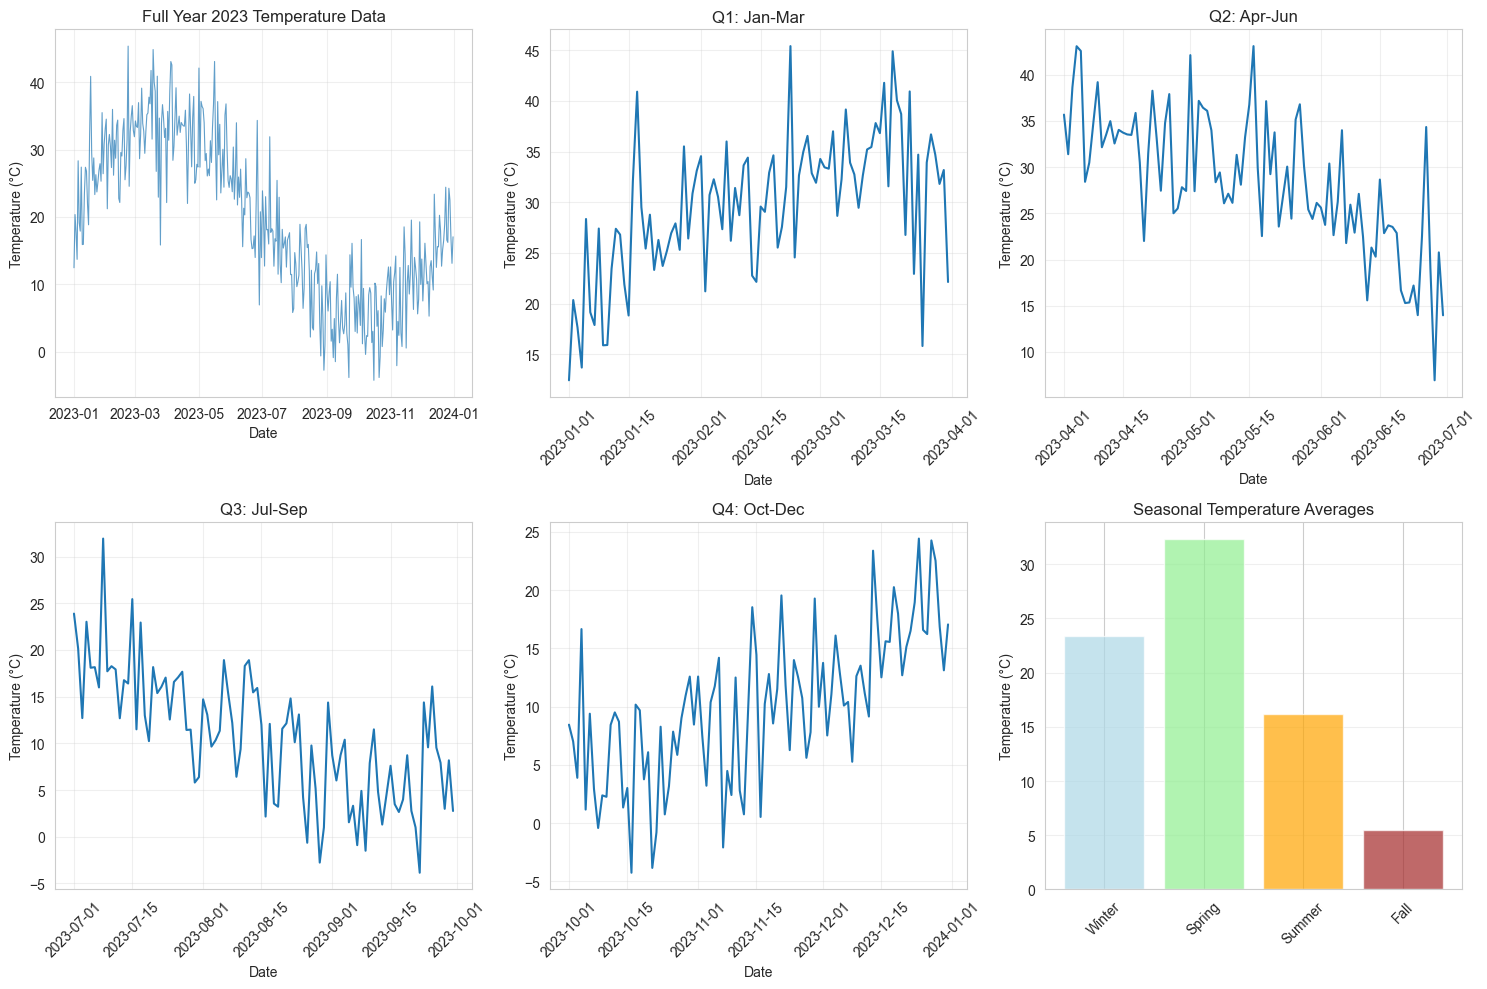


Monthly Temperature Summary:
Jan: Avg =  24.79°C, Min =  12.46°C, Max =  40.89°C
Feb: Avg =  30.77°C, Min =  21.22°C, Max =  45.38°C
Mar: Avg =  33.63°C, Min =  15.83°C, Max =  44.88°C
Apr: Avg =  32.99°C, Min =  22.01°C, Max =  43.09°C
May: Avg =  30.92°C, Min =  22.54°C, Max =  43.10°C
Jun: Avg =  21.92°C, Min =   6.93°C, Max =  34.35°C
Jul: Avg =  16.53°C, Min =   5.80°C, Max =  31.92°C
Aug: Avg =  10.19°C, Min =  -2.76°C, Max =  18.91°C
Sep: Avg =   5.63°C, Min =  -3.85°C, Max =  16.09°C
Oct: Avg =   5.56°C, Min =  -4.26°C, Max =  16.65°C
Nov: Avg =   9.48°C, Min =  -2.09°C, Max =  19.54°C
Dec: Avg =  15.12°C, Min =   5.27°C, Max =  24.42°C


In [14]:
# Generating time series data for the year 2023
print("Exercise 8 - Time Series Data Manipulation:")

# Creating complete year 2023 date range
dates_2023 = np.arange('2023-01-01', '2024-01-01', dtype='datetime64[D]')
print(f"Generated {len(dates_2023)} dates for year 2023")
print(f"Date range: {dates_2023[0]} to {dates_2023[-1]}")

# Generating corresponding time series values 
np.random.seed(50)
# Creating seasonal pattern with noise
day_of_year = np.arange(1, len(dates_2023) + 1)
seasonal_pattern = 20 + 15 * np.sin(2 * np.pi * day_of_year / 365.25)  # Seasonal cycle
noise = np.random.normal(0, 5, len(dates_2023))  # Random variation
temperature_values = seasonal_pattern + noise

print(f"Sample temperature values: {temperature_values[:10]}")

# Demonstrating slicing for different intervals
print(f"\nTime Series Slicing Demonstrations:")

# 1. January to March (Q1)
jan_to_mar_mask = (dates_2023 >= np.datetime64('2023-01-01')) & (dates_2023 <= np.datetime64('2023-03-31'))
jan_to_mar_dates = dates_2023[jan_to_mar_mask]
jan_to_mar_values = temperature_values[jan_to_mar_mask]

print(f"\n1. January to March:")
print(f"   Period: {jan_to_mar_dates[0]} to {jan_to_mar_dates[-1]}")
print(f"   Number of days: {len(jan_to_mar_dates)}")
print(f"   Average temperature: {np.mean(jan_to_mar_values):.2f}°C")

# 2. April to June (Q2)
apr_to_jun_mask = (dates_2023 >= np.datetime64('2023-04-01')) & (dates_2023 <= np.datetime64('2023-06-30'))
apr_to_jun_dates = dates_2023[apr_to_jun_mask]
apr_to_jun_values = temperature_values[apr_to_jun_mask]

print(f"\n2. April to June:")
print(f"   Period: {apr_to_jun_dates[0]} to {apr_to_jun_dates[-1]}")
print(f"   Number of days: {len(apr_to_jun_dates)}")
print(f"   Average temperature: {np.mean(apr_to_jun_values):.2f}°C")

# 3. July to September (Q3)
jul_to_sep_mask = (dates_2023 >= np.datetime64('2023-07-01')) & (dates_2023 <= np.datetime64('2023-09-30'))
jul_to_sep_dates = dates_2023[jul_to_sep_mask]
jul_to_sep_values = temperature_values[jul_to_sep_mask]

print(f"\n3. July to September:")
print(f"   Period: {jul_to_sep_dates[0]} to {jul_to_sep_dates[-1]}")
print(f"   Number of days: {len(jul_to_sep_dates)}")
print(f"   Average temperature: {np.mean(jul_to_sep_values):.2f}°C")

# 4. October to December (Q4)
oct_to_dec_mask = (dates_2023 >= np.datetime64('2023-10-01')) & (dates_2023 <= np.datetime64('2023-12-31'))
oct_to_dec_dates = dates_2023[oct_to_dec_mask]
oct_to_dec_values = temperature_values[oct_to_dec_mask]

print(f"\n4. October to December:")
print(f"   Period: {oct_to_dec_dates[0]} to {oct_to_dec_dates[-1]}")
print(f"   Number of days: {len(oct_to_dec_dates)}")
print(f"   Average temperature: {np.mean(oct_to_dec_values):.2f}°C")

# Additional slicing examples
print(f"\nAdditional Time Series Slicing Examples:")

# Summer months (June, July, August)
summer_mask = (dates_2023 >= np.datetime64('2023-06-01')) & (dates_2023 <= np.datetime64('2023-08-31'))
summer_temps = temperature_values[summer_mask]
print(f"Summer average temperature: {np.mean(summer_temps):.2f}°C")

# Winter months (December, January, February)
winter_mask = ((dates_2023 >= np.datetime64('2023-12-01')) & (dates_2023 <= np.datetime64('2023-12-31'))) | \
              ((dates_2023 >= np.datetime64('2023-01-01')) & (dates_2023 <= np.datetime64('2023-02-28')))
winter_temps = temperature_values[winter_mask]
print(f"Winter average temperature: {np.mean(winter_temps):.2f}°C")

# Specific month slicing
july_mask = (dates_2023 >= np.datetime64('2023-07-01')) & (dates_2023 <= np.datetime64('2023-07-31'))
july_temps = temperature_values[july_mask]
print(f"July average temperature: {np.mean(july_temps):.2f}°C")

plt.figure(figsize=(15, 10))

# Full year plot (taking position 1)
plt.subplot(2, 3, 1)
plt.plot(dates_2023, temperature_values, linewidth=0.8, alpha=0.7)
plt.title('Full Year 2023 Temperature Data')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)

# Quarterly plots (taking positions 2, 3, 4, 5)
quarters = [
    (jan_to_mar_dates, jan_to_mar_values, 'Q1: Jan-Mar'),
    (apr_to_jun_dates, apr_to_jun_values, 'Q2: Apr-Jun'),
    (jul_to_sep_dates, jul_to_sep_values, 'Q3: Jul-Sep'),
    (oct_to_dec_dates, oct_to_dec_values, 'Q4: Oct-Dec')
]

for i, (dates, values, title) in enumerate(quarters):
    plt.subplot(2, 3, i+2)  # positions 2, 3, 4, 5
    plt.plot(dates, values, linewidth=1.5)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

# Add a summary plot comparing seasons (position 6)
plt.subplot(2, 3, 6)
seasonal_data = [
    np.mean(winter_temps),
    np.mean(jan_to_mar_values[jan_to_mar_values.shape[0]//3:]),  # Spring (March part)
    np.mean(summer_temps),
    np.mean(oct_to_dec_values[:oct_to_dec_values.shape[0]//3])   # Fall (October part)
]
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
plt.bar(seasons, seasonal_data, color=['lightblue', 'lightgreen', 'orange', 'brown'], alpha=0.7)
plt.title('Seasonal Temperature Averages')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Monthly aggregation summary
print(f"\nMonthly Temperature Summary:")
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, month in enumerate(months):
    month_start = np.datetime64(f'2023-{i+1:02d}-01')
    if i == 11:  # December
        month_end = np.datetime64('2023-12-31')
    else:
        month_end = np.datetime64(f'2023-{i+2:02d}-01')
    
    month_mask = (dates_2023 >= month_start) & (dates_2023 < month_end)
    month_temps = temperature_values[month_mask]
    
    print(f"{month}: Avg = {np.mean(month_temps):6.2f}°C, "
          f"Min = {np.min(month_temps):6.2f}°C, "
          f"Max = {np.max(month_temps):6.2f}°C")

## Exercise 9: Data Conversion

In [11]:
# Data conversion between NumPy arrays and Pandas DataFrames
print("Exercise 9 - Data Conversion:")
print("Demonstrating conversion between NumPy arrays and Pandas DataFrames")
print("-" * 65)

#  NumPy arrays
print("1. Converting NumPy Array to Pandas DataFrame:")

#  sample NumPy arrays
np.random.seed(200)
numeric_array = np.random.randn(5, 4) * 10 + 50
print("Original NumPy array:")
print(numeric_array)
print(f"Array shape: {numeric_array.shape}")
print(f"Array dtype: {numeric_array.dtype}")

# Method 1: Basic conversion
df_basic = pd.DataFrame(numeric_array)
print(f"\nMethod 1 - Basic conversion:")
print(df_basic)

# Method 2: Conversion with custom labels
column_names = ['Temperature', 'Humidity', 'Pressure', 'Wind_Speed']
index_names = ['City_A', 'City_B', 'City_C', 'City_D', 'City_E']

df_labeled = pd.DataFrame(
    data=numeric_array,
    index=index_names,
    columns=column_names
)
print(f"\nMethod 2 - Conversion with custom labels:")
print(df_labeled)

# Method 3: Multiple arrays to DataFrame
temperatures = np.random.normal(25, 5, 6)
dates = pd.date_range('2023-01-01', periods=6, freq='M')
cities = ['New York', 'London', 'Tokyo', 'Sydney', 'Paris', 'Toronto']

df_multi_arrays = pd.DataFrame({
    'City': cities,
    'Date': dates,
    'Temperature': temperatures,
    'Above_Average': temperatures > temperatures.mean()
})
print(f"\nMethod 3 - Multiple arrays combined:")
print(df_multi_arrays)

print(f"\n" + "="*65)
print("2. Converting Pandas DataFrame to NumPy Array:")

# Starting with a DataFrame
sample_df = pd.DataFrame({
    'A': [1, 2, 3, 4, 5],
    'B': [10.5, 20.3, 30.1, 40.7, 50.2],
    'C': ['X', 'Y', 'X', 'Z', 'Y'],
    'D': [True, False, True, False, True]
})
print("Original DataFrame:")
print(sample_df)
print(f"DataFrame shape: {sample_df.shape}")
print(f"DataFrame dtypes:")
print(sample_df.dtypes)

# Method 1: Convert all numeric columns
numeric_columns = sample_df.select_dtypes(include=[np.number])
numeric_array = numeric_columns.values
print(f"\nMethod 1 - Numeric columns only:")
print(f"Selected columns: {list(numeric_columns.columns)}")
print(numeric_array)
print(f"Resulting array shape: {numeric_array.shape}")

# Method 2: Convert specific columns
specific_array = sample_df[['A', 'B']].values
print(f"\nMethod 2 - Specific columns (A, B):")
print(specific_array)

# Method 3: Convert with different data types
# Converting categorical to numeric codes
df_encoded = sample_df.copy()
df_encoded['C'] = pd.Categorical(df_encoded['C']).codes
df_encoded['D'] = df_encoded['D'].astype(int)

full_array = df_encoded.values
print(f"\nMethod 3 - All columns (encoded):")
print("Encoded DataFrame:")
print(df_encoded)
print("Resulting array:")
print(full_array)

# Method 4: Converting index and values separately
print(f"\nMethod 4 - Separating index and values:")
values_array = df_labeled.values
index_array = np.array(df_labeled.index)
columns_array = np.array(df_labeled.columns)

print(f"Values array shape: {values_array.shape}")
print(f"Index array: {index_array}")
print(f"Columns array: {columns_array}")

# Round-trip conversion demonstration
print(f"\n" + "="*65)
print("3. Round-trip Conversion Demonstration:")

# Original NumPy array
original_array = np.random.randint(1, 100, size=(3, 4))
print("Original NumPy array:")
print(original_array)

# Convert to DataFrame and back
temp_df = pd.DataFrame(original_array, 
                      index=['Row1', 'Row2', 'Row3'],
                      columns=['Col1', 'Col2', 'Col3', 'Col4'])
back_to_array = temp_df.values

print(f"\nAfter round-trip conversion:")
print(back_to_array)
print(f"Arrays are equal: {np.array_equal(original_array, back_to_array)}")

# Performance comparison
print(f"\n" + "="*65)
print("4. Conversion Performance Notes:")

large_array = np.random.randn(1000, 10)
print(f"Large array shape: {large_array.shape}")

# Timing the conversions 
import time

start_time = time.time()
large_df = pd.DataFrame(large_array)
df_conversion_time = time.time() - start_time

start_time = time.time()
back_to_large_array = large_df.values
array_conversion_time = time.time() - start_time

print(f"NumPy to DataFrame conversion time: {df_conversion_time:.6f} seconds")
print(f"DataFrame to NumPy conversion time: {array_conversion_time:.6f} seconds")

# Memory usage comparison
print(f"\nMemory usage comparison:")
print(f"NumPy array memory usage: {large_array.nbytes} bytes")
print(f"DataFrame memory usage: {large_df.memory_usage(deep=True).sum()} bytes")

Exercise 9 - Data Conversion:
Demonstrating conversion between NumPy arrays and Pandas DataFrames
-----------------------------------------------------------------
1. Converting NumPy Array to Pandas DataFrame:
Original NumPy array:
[[35.49051751 69.10953134 57.11879154 47.52261713]
 [53.61466235 49.67050329 47.78653282 54.77256777]
 [43.08060626 57.9200593  50.73249134 63.03286033]
 [52.1348149  60.17348953 69.11711781 44.70328369]
 [68.42135158 39.42764918 41.37083714 52.37631497]]
Array shape: (5, 4)
Array dtype: float64

Method 1 - Basic conversion:
           0          1          2          3
0  35.490518  69.109531  57.118792  47.522617
1  53.614662  49.670503  47.786533  54.772568
2  43.080606  57.920059  50.732491  63.032860
3  52.134815  60.173490  69.117118  44.703284
4  68.421352  39.427649  41.370837  52.376315

Method 2 - Conversion with custom labels:
        Temperature   Humidity   Pressure  Wind_Speed
City_A    35.490518  69.109531  57.118792   47.522617
City_B    53.

C:\Users\PC\AppData\Local\Temp\ipykernel_15520\3058564074.py:36: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2023-01-01', periods=6, freq='M')


## Exercise 10: Basic Visualization

Exercise 10 - Basic Visualization:
Creating visualizations with NumPy data using Matplotlib
-------------------------------------------------------
Generated datasets for visualization:
Line data: 50 points
Multiple series: 20 points each
Scatter data: 100 points


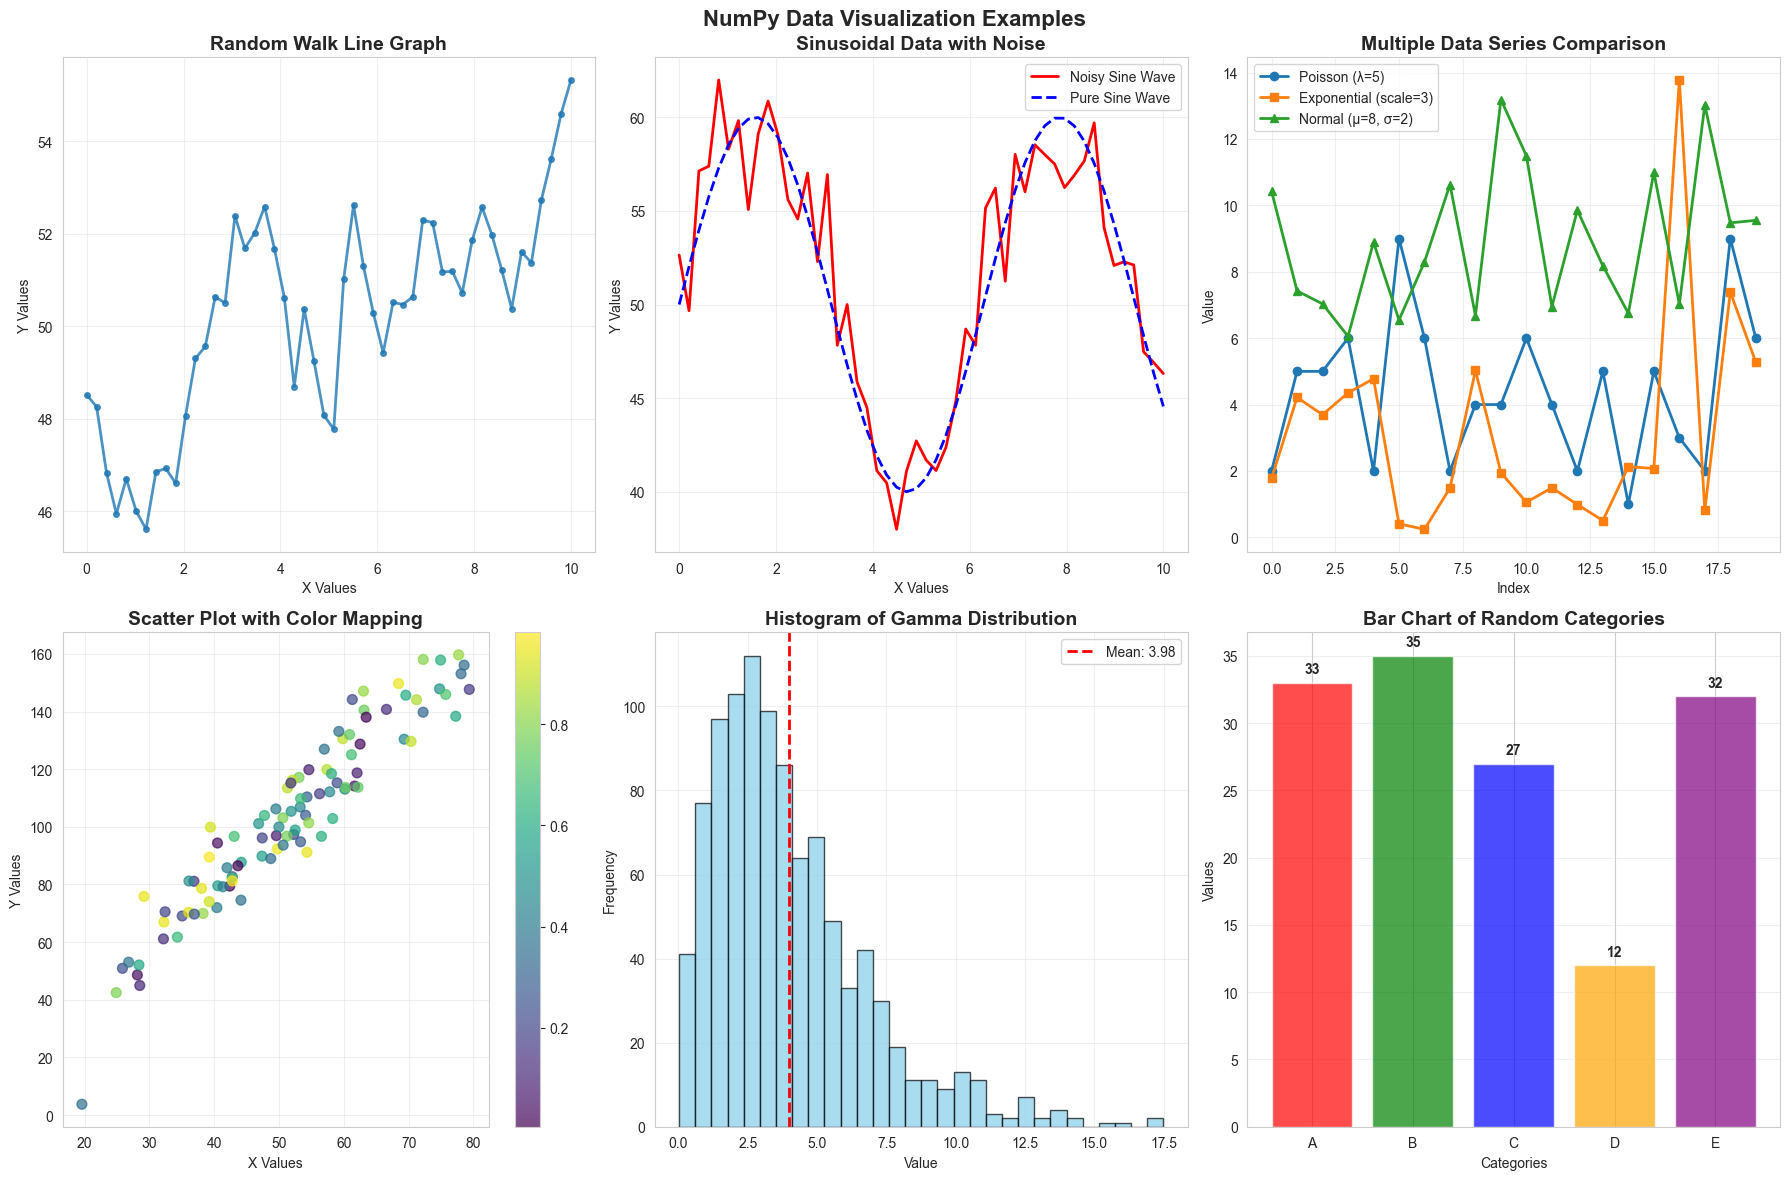


Advanced Visualization Examples:


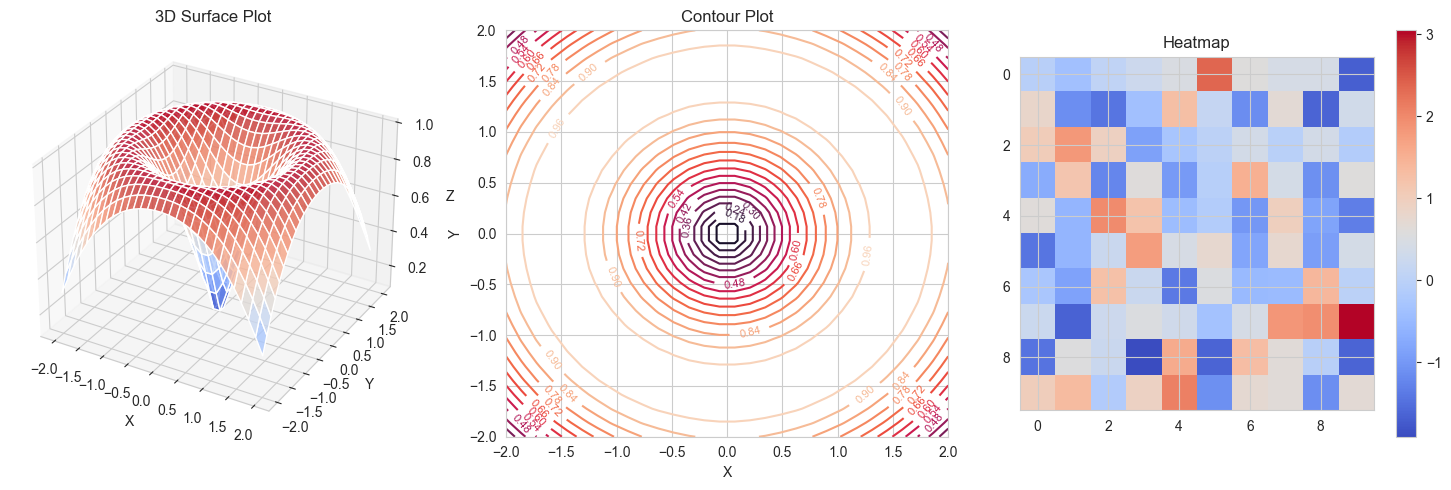

C:\Users\PC\AppData\Local\Temp\ipykernel_15520\331517048.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(box_data, labels=['Dataset 1', 'Dataset 2', 'Dataset 3'])


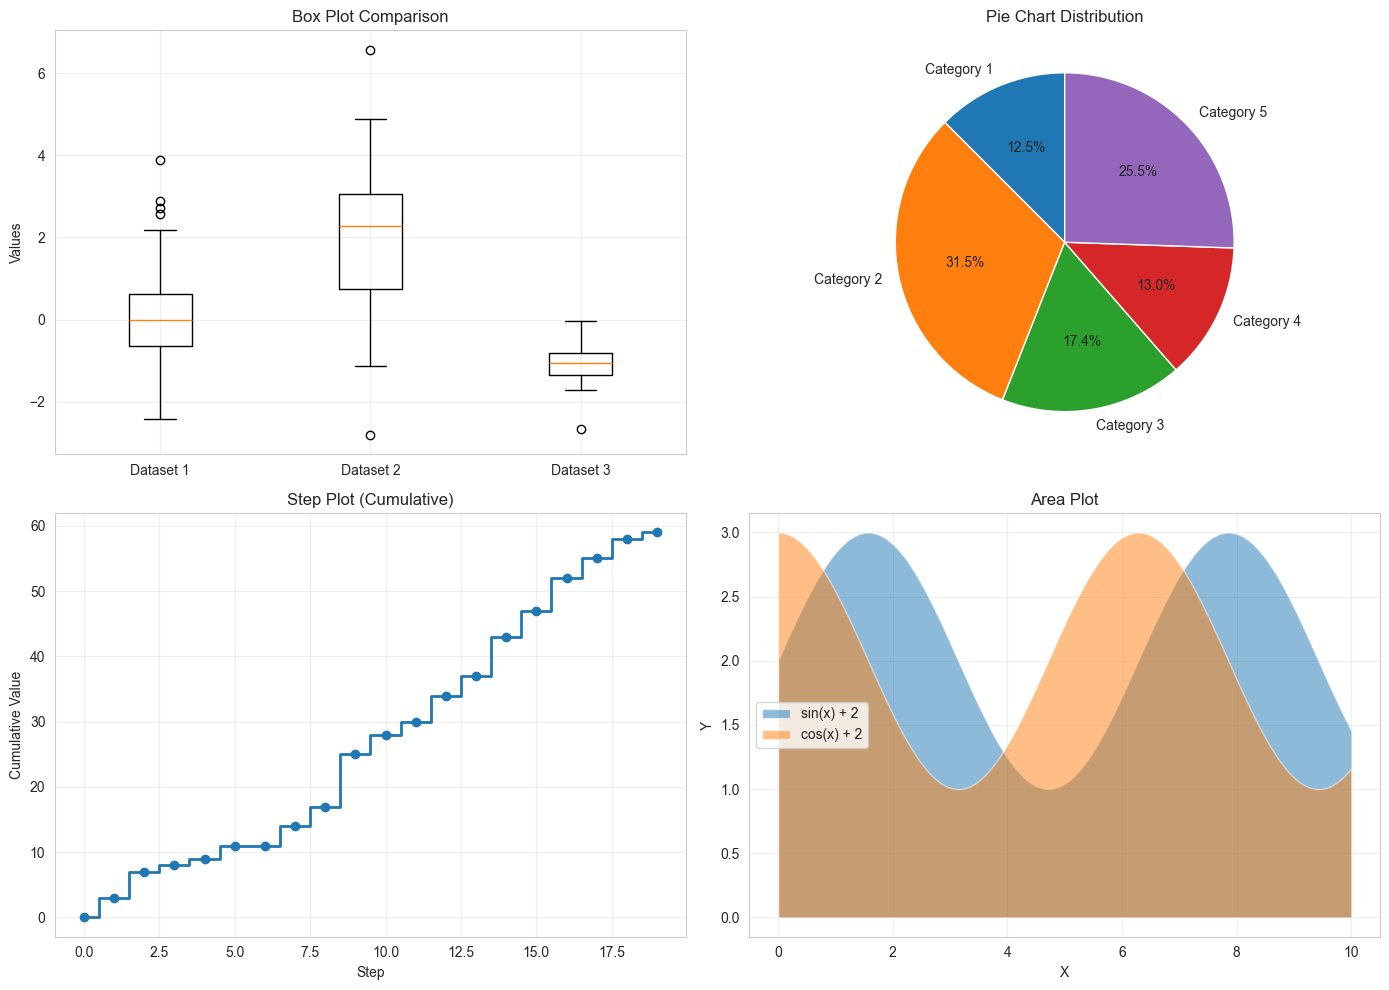

All visualization examples completed successfully!


In [12]:
print("Exercise 10 - Basic Visualization:")
print("Creating visualizations with NumPy data using Matplotlib")
print("-" * 55)

np.random.seed(300)

# Dataset 1: Simple line graph with random numbers
x_values = np.linspace(0, 10, 50)
y_random = np.random.randn(50).cumsum() + 50  # Random walk
y_smooth = 50 + 10 * np.sin(x_values) + np.random.normal(0, 2, 50)  # Sinusoidal with noise

# Dataset 2: Multiple series for comparison
x_data = np.arange(0, 20)
series1 = np.random.poisson(lam=5, size=20)
series2 = np.random.exponential(scale=3, size=20)
series3 = np.random.normal(loc=8, scale=2, size=20)

# Dataset 3: 2D data for scatter plot
scatter_x = np.random.normal(50, 15, 100)
scatter_y = 2 * scatter_x + np.random.normal(0, 10, 100)
colors = np.random.rand(100)

print("Generated datasets for visualization:")
print(f"Line data: {len(x_values)} points")
print(f"Multiple series: {len(x_data)} points each")
print(f"Scatter data: {len(scatter_x)} points")

# Creating comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Simple line graph
axes[0, 0].plot(x_values, y_random, linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[0, 0].set_title('Random Walk Line Graph', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('X Values')
axes[0, 0].set_ylabel('Y Values')
axes[0, 0].grid(True, alpha=0.3)

# 2. Smooth curve with noise
axes[0, 1].plot(x_values, y_smooth, 'r-', linewidth=2, label='Noisy Sine Wave')
axes[0, 1].plot(x_values, 50 + 10 * np.sin(x_values), 'b--', linewidth=2, label='Pure Sine Wave')
axes[0, 1].set_title('Sinusoidal Data with Noise', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('X Values')
axes[0, 1].set_ylabel('Y Values')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Multiple series comparison
axes[0, 2].plot(x_data, series1, 'o-', label='Poisson (λ=5)', linewidth=2, markersize=6)
axes[0, 2].plot(x_data, series2, 's-', label='Exponential (scale=3)', linewidth=2, markersize=6)
axes[0, 2].plot(x_data, series3, '^-', label='Normal (μ=8, σ=2)', linewidth=2, markersize=6)
axes[0, 2].set_title('Multiple Data Series Comparison', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Index')
axes[0, 2].set_ylabel('Value')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Scatter plot with color mapping
scatter = axes[1, 0].scatter(scatter_x, scatter_y, c=colors, s=50, alpha=0.7, cmap='viridis')
axes[1, 0].set_title('Scatter Plot with Color Mapping', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('X Values')
axes[1, 0].set_ylabel('Y Values')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0])

# 5. Histogram of random data
hist_data = np.random.gamma(2, 2, 1000)  # Gamma distribution
axes[1, 1].hist(hist_data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 1].axvline(np.mean(hist_data), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {np.mean(hist_data):.2f}')
axes[1, 1].set_title('Histogram of Gamma Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Bar chart
categories = ['A', 'B', 'C', 'D', 'E']
values = np.random.randint(10, 50, 5)
bars = axes[1, 2].bar(categories, values, color=['red', 'green', 'blue', 'orange', 'purple'], alpha=0.7)
axes[1, 2].set_title('Bar Chart of Random Categories', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Categories')
axes[1, 2].set_ylabel('Values')
axes[1, 2].grid(True, alpha=0.3, axis='y')

# Adding value labels on bars
for bar, value in zip(bars, values):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    str(value), ha='center', va='bottom', fontweight='bold')

plt.suptitle('NumPy Data Visualization Examples', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\nAdvanced Visualization Examples:")

# 3D surface plot
fig = plt.figure(figsize=(15, 5))

# Creating 3D data
x_3d = np.linspace(-2, 2, 30)
y_3d = np.linspace(-2, 2, 30)
X, Y = np.meshgrid(x_3d, y_3d)
Z = np.sin(np.sqrt(X**2 + Y**2))

# 3D surface plot
ax1 = fig.add_subplot(131, projection='3d')
surface = ax1.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8)
ax1.set_title('3D Surface Plot')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Contour plot
ax2 = fig.add_subplot(132)
contour = ax2.contour(X, Y, Z, levels=15)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_title('Contour Plot')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

# Heatmap
ax3 = fig.add_subplot(133)
heatmap_data = np.random.randn(10, 10)
heatmap = ax3.imshow(heatmap_data, cmap='coolwarm', interpolation='nearest')
ax3.set_title('Heatmap')
plt.colorbar(heatmap, ax=ax3)

plt.tight_layout()
plt.show()

# Statistical plots using NumPy data
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Box plot data
box_data = [np.random.normal(0, 1, 100), 
           np.random.normal(2, 1.5, 100), 
           np.random.normal(-1, 0.5, 100)]

ax1.boxplot(box_data, labels=['Dataset 1', 'Dataset 2', 'Dataset 3'])
ax1.set_title('Box Plot Comparison')
ax1.set_ylabel('Values')
ax1.grid(True, alpha=0.3)

# Pie chart
pie_data = np.random.randint(10, 100, 5)
pie_labels = ['Category ' + str(i+1) for i in range(5)]
ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax2.set_title('Pie Chart Distribution')

# Step plot
step_x = np.arange(0, 20)
step_y = np.random.poisson(3, 20).cumsum()
ax3.step(step_x, step_y, where='mid', linewidth=2, marker='o')
ax3.set_title('Step Plot (Cumulative)')
ax3.set_xlabel('Step')
ax3.set_ylabel('Cumulative Value')
ax3.grid(True, alpha=0.3)

# Area plot
area_x = np.linspace(0, 10, 100)
area_y1 = np.sin(area_x) + 2
area_y2 = np.cos(area_x) + 2
ax4.fill_between(area_x, area_y1, alpha=0.5, label='sin(x) + 2')
ax4.fill_between(area_x, area_y2, alpha=0.5, label='cos(x) + 2')
ax4.set_title('Area Plot')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("All visualization examples completed successfully!")